# 2 - Complex thing

In [1]:
#Imports
import PV_ICE
import pandas as pd
import numpy as np
import json
import os
import tqdm
import matplotlib.pyplot as plt

In [2]:
import hail_model as hs

In [3]:
# This information helps with debugging and getting support :)
import sys, platform
print("Working on a ", platform.system(), platform.release())
print("Python version ", sys.version)
print("Pandas version ", pd.__version__)
print("PV_ICE version ", PV_ICE.__version__)

Working on a  Windows 11
Python version  3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Pandas version  2.2.3
PV_ICE version  0.2.1.dev710+g684c1eea6.d20260402


In [4]:
from PV_ICE.main import weibull_cdf, weibull_pdf, weibull_params

## Input data

The model currently uses three external data inputs:

- Location-specific hail return periods.
- Location-specific Gamma hail-size distributions.
- Empirical conditional broken-glass damage distributions by hail-size bin.

An additional empirical CDF is used to represent increased degradation
for modules that survive hail exposure.

The broken-glass CSVs are currently approximated from the available
damage-distribution figure and can later be replaced by exact numerical
data without changing the simulation framework.

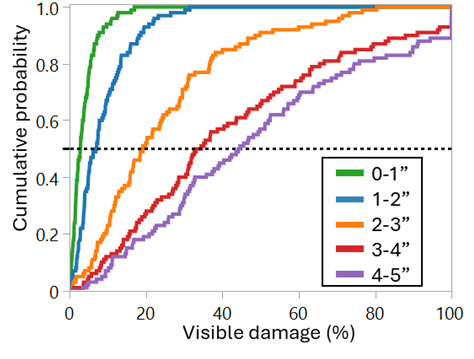

In [5]:
# Hail occurrence and hail-size distributions
hail_return = pd.read_csv("Hail_return_period.csv")
hail_dist = pd.read_csv("Hail_size_distribution_discrete_locations.csv")

# Post-hail degradation distribution
plr_cdf = pd.read_csv("plr_increase_after_1in_hail.csv")
plr_cdf.columns = plr_cdf.columns.str.strip()

# Conditional broken-glass damage distributions
damage_cdfs = {
    "0_1": pd.read_csv("broken_glass_0_1.csv"),
    "1_2": pd.read_csv("broken_glass_1_2.csv"),
    "2_3": pd.read_csv("broken_glass_2_3.csv"),
    "3_4": pd.read_csv("broken_glass_3_4.csv"),
    "4_5": pd.read_csv("broken_glass_4_5.csv"),
}

## Spatial hail coverage modifier

### Why this is needed

The hail return-period data describe how often a hail event occurs within the geographic
area used to calculate the hazard (currently represented by the county).

However, a hailstorm does not necessarily cover the entire county.

Therefore:

**A hail event occurring in the county does not necessarily mean that the PV site is hit.**

Dirk provided an estimate of the median area covered by 2-inch hail and the area of the
county containing each study location.

For the current simplified implementation:

    coverage_fraction = median hail footprint area / county area

This is used as an additional probability that the PV site lies within the hail footprint.

Therefore, the annual probability that the PV site is hit is approximated as:

    P(site hit) = P(county hail event) × P(site within hail footprint)

or:

    P(site hit) = (1 / return_period) × coverage_fraction

### Current assumptions

- The median return period is still used to determine annual hail occurrence.
- The Gamma distribution is still used to sample hail size if the site is hit.
- The empirical conditional damage distributions are still used to sample the fraction
  of modules with broken glass.
- For now, a single median 2-inch hail footprint is used rather than sampling storm area.
- Coverage fraction is capped at 1.0 because a probability cannot exceed 100%.
- This is a first-order spatial exposure approximation. A future version can sample
  hail footprint area as a function of hail size using the provided distributions.

In [6]:
# ------------------------------------------------------------------
# Spatial hail exposure input
# ------------------------------------------------------------------
#
# A county-level hail event does not necessarily hit the PV site.
# This table provides a first-order spatial modifier based on the
# fraction of the county covered by a representative 2-inch hail footprint.
#
# Data provided by Dirk:
#   A_total_sqmi          = county area [mi²]
#   median_hail_area_sqmi = median area covered by 2-inch hail [mi²]
#
# Spatial coverage is calculated as:
#
#   coverage_fraction = hail footprint area / county area
#
# and is interpreted as:
#
#   P(site is within hail footprint | county hail event)
#
# The fraction is capped at 1.0. For Denver, the representative hail
# footprint is larger than the county itself, so coverage is set to 100%.
#
# NOTE: This currently uses a single median 2-inch hail footprint.
# A future refinement could sample hail footprint area as a function
# of hail size using the provided footprint-area distributions.


hail_coverage = pd.DataFrame({
    "Location": ["Austin", "Phoenix", "Denver"],
    "County": ["Travis County", "Maricopa County", "Denver County"],
    "A_total_sqmi": [1025.027, 9225.996, 154.725],
    "median_hail_area_sqmi": [208.496202, 208.496202, 208.496202]
})

# Calculate the fraction of county area covered by the median hail footprint.
hail_coverage["coverage_fraction_raw"] = (
    hail_coverage["median_hail_area_sqmi"] /
    hail_coverage["A_total_sqmi"]
)

# A probability cannot exceed 1.
# Denver's median hail footprint is larger than Denver County, so the
# simplified coverage probability is capped at 100%.
hail_coverage["coverage_fraction"] = (
    hail_coverage["coverage_fraction_raw"].clip(upper=1.0)
)

hail_coverage

,Location,County,A_total_sqmi,median_hail_area_sqmi,coverage_fraction_raw,coverage_fraction
0,Austin,Travis County,1025.027,208.496202,0.203406,0.203406
1,Phoenix,Maricopa County,9225.996,208.496202,0.022599,0.022599
2,Denver,Denver County,154.725,208.496202,1.347528,1.000000


## Hazard-input sanity check

Before running the simulation, verify the annual probabilities implied
by the return-period and spatial-coverage assumptions.

This does not run the reliability model; it only checks the hazard
inputs used by `simulate_project()`.

In [7]:
# ------------------------------------------------------------------
# Sanity check: annual site-level hail probability by location
# ------------------------------------------------------------------
#
# This compares the hail occurrence assumptions for the three study
# locations before running the project simulations.
#
# For each location:
#
#   1. Get the median hail return period (RP).
#
#   2. Convert RP to the annual probability that the modeled hail
#      event occurs somewhere in the county:
#
#           P(county event) = 1 / RP
#
#   3. Get the spatial coverage fraction, which approximates the
#      probability that the PV site lies within the hail footprint
#      given that the county experiences the event.
#
#   4. Combine occurrence and spatial exposure:
#
#           P(site hit) = (1 / RP) * coverage_fraction
#
# This cell does NOT run a simulation. It only verifies the hazard
# probabilities that will be used by simulate_project().

for location in ["Denver", "Phoenix", "Austin"]:

    rp = hs.get_return_period(location, hail_return)
    coverage = hs.get_coverage_fraction(location, hail_coverage)
    p_site = hs.get_annual_site_hail_probability(location, hail_return, hail_coverage)

    print(f"{location}")
    print(f"  Median return period:       {rp:.1f} years")
    print(f"  County event probability:   {1/rp:.3%} per year")
    print(f"  Spatial coverage fraction:  {coverage:.3%}")
    print(f"  Site-hit probability:       {p_site:.3%} per year")
    print()

Denver
  Median return period:       9.0 years
  County event probability:   11.111% per year
  Spatial coverage fraction:  100.000%
  Site-hit probability:       11.111% per year

Phoenix
  Median return period:       16.0 years
  County event probability:   6.250% per year
  Spatial coverage fraction:  2.260%
  Site-hit probability:       0.141% per year

Austin
  Median return period:       6.0 years
  County event probability:   16.667% per year
  Spatial coverage fraction:  20.341%
  Site-hit probability:       3.390% per year



## Baseline simulation assumptions

The initial example represents a 100-MW project evaluated over 50 years.
Intrinsic module reliability is represented using a Weibull distribution
defined by \(t_{50}=39\) years and \(t_{90}=42\) years.

In [8]:
rng = np.random.default_rng(42)
P0_MW = 100
years = np.arange(0, 51)
location = 'Austin'

T50 = 39
T90 = 42

N_SIMS = 200
BASE_SEED = 100

### Hail damage implementation

For each simulated site-level hail event:

1. Hail size is sampled from the location-specific Gamma distribution.
2. The hail size selects the corresponding conditional damage distribution.
3. A catastrophic damage fraction (`f_cat`) is sampled from that distribution.
4. `f_cat` represents the fraction of surviving project capacity experiencing
   broken-glass failure; it is not a module failure probability.

A fragility curve is therefore not currently used in the model.

## Single-project simulation

For each year, the model:

1. Applies intrinsic Weibull reliability failures to the physically
   surviving project capacity.
2. Samples whether a hail event affects the site.
3. If hail occurs, samples hail size from the location-specific Gamma
   distribution.
4. Samples a catastrophic broken-glass fraction (`f_cat`) from the
   conditional damage distribution associated with that hail-size bin.
5. Updates surviving physical project capacity.
6. Optionally applies an additional degradation rate to hail-damaged
   survivors.



In [11]:
res_city  = hs.simulate_project(
    P0_MW=100,
    location=location,
    years=years,
    damage_cdfs=damage_cdfs,
    hail_return=hail_return,
    hail_dist=hail_dist,
    hail_coverage=hail_coverage,
    plr_cdf=plr_cdf,
    t50=39,
    t90=42,
    seed=42,
    use_post_hail_plr=True,
    track_hail_buckets=True, 
    apply_plr_once=True, 
    debug=True
)


PLR branch entered at year 19
use_post_hail_plr = True
plr_cdf is None = False
sampled_plr = 0.0072772778680906414
PLR branch entered at year 34
use_post_hail_plr = True
plr_cdf is None = False
sampled_plr = 0.012595298180927346


In [12]:

res_city.head()

,year,hail_event,hail_size_in,f_rel,f_cat,plr_added_this_year,cumulative_extra_plr_per_year,undamaged_MW_end,hail_damaged_MW_end,available_capacity_MW_end,effective_capacity_MW_end,reliability_failures_MW,hail_failures_MW,total_failures_MW,S_total,available_capacity_MW_start
0,0,False,0.0,0.000000e+00,0.0,0.0,0.0,100.0,0.0,100.0,100.0,0.000000e+00,0.0,0.000000e+00,1.0,100.0
1,1,False,0.0,0.000000e+00,0.0,0.0,0.0,100.0,0.0,100.0,100.0,0.000000e+00,0.0,0.000000e+00,1.0,100.0
2,2,False,0.0,0.000000e+00,0.0,0.0,0.0,100.0,0.0,100.0,100.0,0.000000e+00,0.0,0.000000e+00,1.0,100.0
3,3,False,0.0,0.000000e+00,0.0,0.0,0.0,100.0,0.0,100.0,100.0,0.000000e+00,0.0,0.000000e+00,1.0,100.0
4,4,False,0.0,1.110223e-16,0.0,0.0,0.0,100.0,0.0,100.0,100.0,1.110223e-14,0.0,1.110223e-14,1.0,100.0


In [14]:
# check whether the simulation actually generated a relevant hail event and PLR:
res_city[[
    "year",
    "hail_event",
    "hail_size_in",
    "f_cat",
    "plr_added_this_year",
    "cumulative_extra_plr_per_year",
    "available_capacity_MW_end",
    "effective_capacity_MW_end"
]][res_city["hail_event"] == True]

,year,hail_event,hail_size_in,f_cat,plr_added_this_year,cumulative_extra_plr_per_year,available_capacity_MW_end,effective_capacity_MW_end
19,19,True,1.438594,0.148686,0.007277,0.007277,85.130876,85.130876
34,34,True,0.469296,0.076707,0.000000,0.007277,72.915701,65.349233


In [15]:
# printout
'''
res_city [[
    "year",
    "available_capacity_MW_start",
    "hail_event",
    "hail_size_in",
    "reliability_failures_MW",
    "hail_failures_MW",
    "total_failures_MW",
    "f_cat",
    "plr_added_this_year",
    "cumulative_extra_plr_per_year",
    "available_capacity_MW_end",
    "effective_capacity_MW_end"
]]
''';

### Cause-specific failure accounting

Intrinsic Weibull failures and catastrophic hail failures are tracked
separately so their contributions to project capacity loss can be
evaluated independently.

In [26]:
summary_year = 30

row = res_city.loc[res_city["year"] == summary_year].iloc[0]

summary = {
    "Summary year":
        summary_year,


    "Hail events through summary year":
        res_city.loc[
            res_city["year"] <= summary_year,
            "hail_event"
        ].sum(),
        
    "Physical capacity [MW]":
        row["available_capacity_MW_end"],

    "Effective capacity [MW]":
        row["effective_capacity_MW_end"],

    "Cumulative reliability failures [MW]":
        res_city.loc[
            res_city["year"] <= summary_year,
            "reliability_failures_MW"
        ].sum(),

    "Cumulative hail failures [MW]":
        res_city.loc[
            res_city["year"] <= summary_year,
            "hail_failures_MW"
        ].sum(),

    "Cumulative physical failures [MW]":
        res_city.loc[
            res_city["year"] <= summary_year,
            "total_failures_MW"
        ].sum(),

    "Post-hail performance loss [MW]":
        row["available_capacity_MW_end"]
        - row["effective_capacity_MW_end"],

    "Total effective capacity loss [MW]":
    P0_MW - row["effective_capacity_MW_end"],
    
    "Effective capacity remaining [%]":
        100 * row["effective_capacity_MW_end"] / P0_MW,
        
}


summary_df = pd.DataFrame(
    summary.items(),
    columns=["Metric", "Value"]
)

summary_df["Value"] = summary_df["Value"].apply(
    lambda x: round(float(x), 2)
    if isinstance(x, (int, float, np.number))
    else x
)

summary_df

,Metric,Value
0,Summary year,30.00
1,Hail events through summary year,1.00
2,Physical capacity [MW],84.29
3,Effective capacity [MW],77.79
4,Cumulative reliability failures [MW],0.84
5,Cumulative hail failures [MW],14.87
6,Cumulative physical failures [MW],15.71
7,Post-hail performance loss [MW],6.51
8,Total effective capacity loss [MW],22.21
9,Effective capacity remaining [%],77.79


In [29]:
''' Snaity check plr is applied
res_city.loc[
    res_city["year"].isin([16,17,18,19,20,21,22]),
    [
        "year",
        "hail_event",
        "plr_added_this_year",
        "cumulative_extra_plr_per_year",
        "available_capacity_MW_end",
        "effective_capacity_MW_end"
    ]
]
''';

In [31]:
# Sanity check -- these two values should match apart from tiny fp differences
'''
print(
    res_city["total_failures_MW"].sum(),
    res_city["reliability_failures_MW"].sum()
    + res_city["hail_failures_MW"].sum()
)
''';

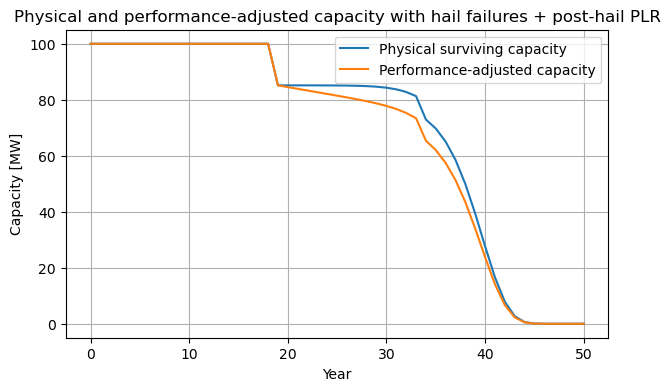

In [32]:
plt.figure(figsize=(7,4))
plt.plot(res_city["year"], res_city["available_capacity_MW_end"], label="Physical surviving capacity")
plt.plot(res_city["year"], res_city["effective_capacity_MW_end"], label="Performance-adjusted capacity")
plt.xlabel("Year")
plt.ylabel("Capacity [MW]")
plt.title("Physical and performance-adjusted capacity with hail failures + post-hail PLR")
plt.legend()
plt.grid(True)
plt.show()

## MonteCarloing

In [33]:
mc = hs.run_monte_carlo(
    n_sims=200,
    P0_MW=100,
    location="Austin",
    years=years,
    damage_cdfs=damage_cdfs,
    hail_return=hail_return,
    hail_dist=hail_dist,
    hail_coverage=hail_coverage,
    plr_cdf=plr_cdf,
    t50=39,
    t90=42,
    base_seed=100,
)

In [34]:
# Summarizing by year
mc_summary = (
    mc.groupby("year")
    .agg(
        physical_p10=("available_capacity_MW_end", lambda x: np.percentile(x, 10)),
        physical_p50=("available_capacity_MW_end", lambda x: np.percentile(x, 50)),
        physical_p90=("available_capacity_MW_end", lambda x: np.percentile(x, 90)),
        effective_p10=("effective_capacity_MW_end", lambda x: np.percentile(x, 10)),
        effective_p50=("effective_capacity_MW_end", lambda x: np.percentile(x, 50)),
        effective_p90=("effective_capacity_MW_end", lambda x: np.percentile(x, 90)),
    )
    .reset_index()
)

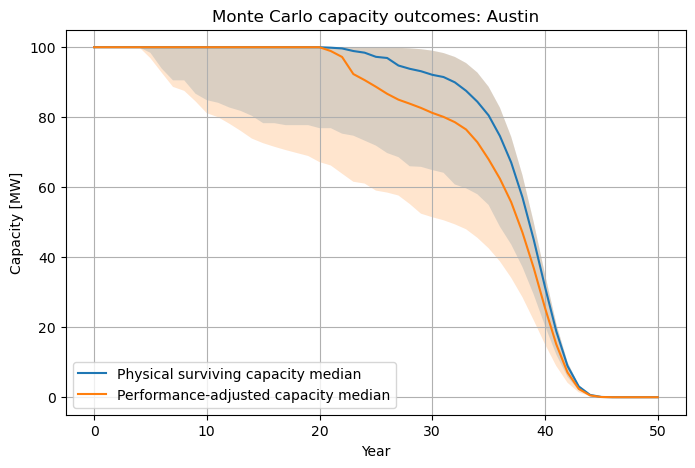

In [75]:
plt.figure(figsize=(8,5))

plt.plot(mc_summary["year"], mc_summary["physical_p50"], label="Physical surviving capacity median")
plt.fill_between(
    mc_summary["year"],
    mc_summary["physical_p10"],
    mc_summary["physical_p90"],
    alpha=0.2
)

plt.plot(mc_summary["year"], mc_summary["effective_p50"], label="Performance-adjusted capacity median")
plt.fill_between(
    mc_summary["year"],
    mc_summary["effective_p10"],
    mc_summary["effective_p90"],
    alpha=0.2
)

plt.xlabel("Year")
plt.ylabel("Capacity [MW]")
plt.title(f"Monte Carlo capacity outcomes: {location}")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
evaluation_year = mc[mc["year"] == summary_year]

evaluation_year[[
    "available_capacity_MW_end",
    "effective_capacity_MW_end",
    "S_total"
]].describe(percentiles=[0.1, 0.5, 0.9])

,available_capacity_MW_end,effective_capacity_MW_end,S_total
count,200.000000,200.000000,200.000000
mean,86.833967,79.171598,0.868340
std,15.641003,19.745492,0.156410
min,25.249164,22.642992,0.252492
10%,64.910773,51.431122,0.649108
50%,92.120105,81.243075,0.921201
90%,99.016432,99.016432,0.990164
max,99.016432,99.016432,0.990164


In [38]:
hail_counts = (
    mc.groupby("sim")["hail_event"]
    .sum()
    .reset_index(name="n_hail_years")
)

hail_counts.describe(percentiles=[0.1, 0.5, 0.9])

,sim,n_hail_years
count,200.000000,200.000000
mean,99.500000,1.850000
std,57.879185,1.344073
min,0.000000,0.000000
10%,19.900000,0.000000
50%,99.500000,2.000000
90%,179.100000,4.000000
max,199.000000,6.000000


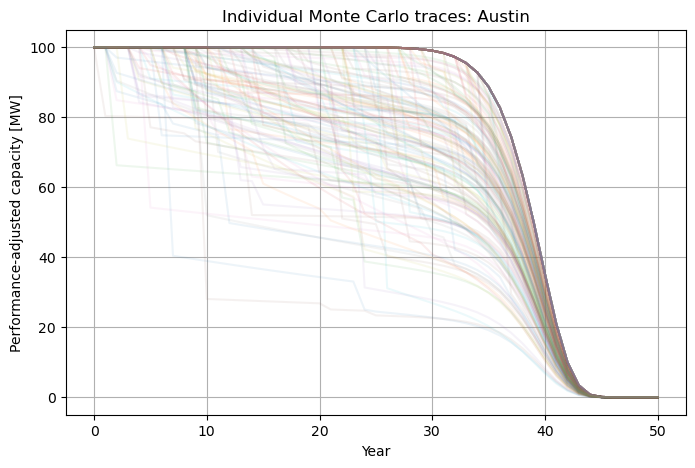

In [39]:
plt.figure(figsize=(8,5))

for sim, g in mc.groupby("sim"):
    plt.plot(g["year"], g["effective_capacity_MW_end"], alpha=0.08)

plt.xlabel("Year")
plt.ylabel("Performance-adjusted capacity [MW]")
plt.title(f"Individual Monte Carlo traces: {location}")
plt.grid(True)
plt.show()

# Comparing between sities now

In [58]:
locations = ["Phoenix", "Austin"]

mc_results = {}

for loc in locations:
    mc_results[loc] = hs.run_monte_carlo(
        n_sims=10000,
        P0_MW=100,
        location=loc,
        years=years,

        # Hazard / damage inputs
        damage_cdfs=damage_cdfs,
        hail_return=hail_return,
        hail_dist=hail_dist,
        hail_coverage=hail_coverage,
        plr_cdf=plr_cdf,

        # Reliability assumptions
        t50=39,
        t90=42,

        # Monte Carlo setup
        base_seed=42,

        # Current preferred post-hail PLR implementation
        use_post_hail_plr=True,
        track_hail_buckets=True,
        apply_plr_once=True,
    )

In [59]:
summaries = {}

for loc, mc_loc in mc_results.items():

    summaries[loc] = (
        mc_loc.groupby("year")
        .agg(
            p10=(
                "effective_capacity_MW_end",
                lambda x: np.percentile(x, 10)
            ),
            median=(
                "effective_capacity_MW_end",
                "median"
            ),
            p90=(
                "effective_capacity_MW_end",
                lambda x: np.percentile(x, 90)
            ),
        )
        .reset_index()
    )

In [60]:
city_evaluation = {}

for loc, mc_loc in mc_results.items():

    city_evaluation[loc] = mc_loc[
        mc_loc["year"] == summary_year
    ]

    print(f"\n{loc} — Year {summary_year}")

    print(
        city_evaluation[loc][
            "effective_capacity_MW_end"
        ].describe(
            percentiles=[0.1, 0.5, 0.9]
        )
    )


Phoenix — Year 30
count    10000.000000
mean        98.119586
std          5.158357
min         28.213152
10%         99.016432
50%         99.016432
90%         99.016432
max         99.016432
Name: effective_capacity_MW_end, dtype: float64

Austin — Year 30
count    10000.000000
mean        80.014632
std         20.399268
min          0.537485
10%         49.735935
50%         84.815477
90%         99.016432
max         99.016432
Name: effective_capacity_MW_end, dtype: float64


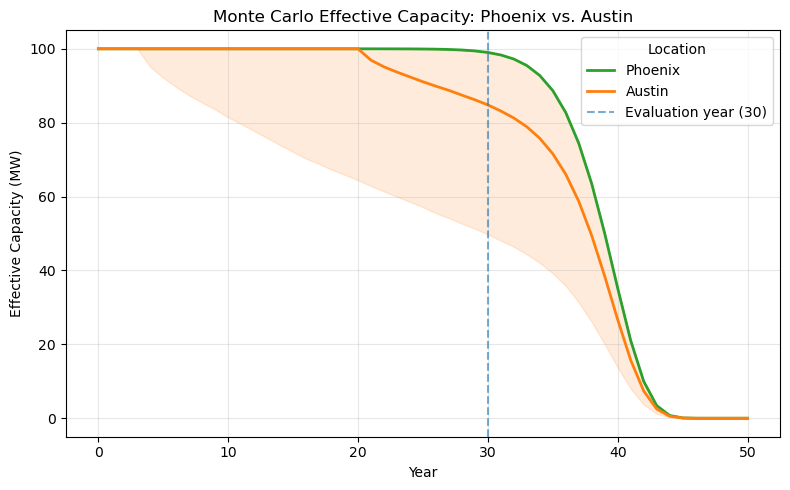

In [61]:
plt.figure(figsize=(8,5))

colors = {
    "Phoenix": "tab:green",
    "Austin": "tab:orange"
}

for loc in locations:

    s = summaries[loc]

    plt.plot(
        s["year"],
        s["median"],
        lw=2,
        label=loc,
        color=colors[loc]
    )

    plt.fill_between(
        s["year"],
        s["p10"],
        s["p90"],
        alpha=0.15,
        color=colors[loc]
    )

# Mark project evaluation year
plt.axvline(
    summary_year,
    linestyle="--",
    alpha=0.6,
    label=f"Evaluation year ({summary_year})"
)

plt.xlabel("Year")
plt.ylabel("Effective Capacity (MW)")
plt.title("Monte Carlo Effective Capacity: Phoenix vs. Austin")

plt.grid(alpha=0.3)
plt.legend(title="Location")
plt.tight_layout()
plt.show()

In [62]:
for loc in locations:
    s = summaries[loc]

    row30 = s.loc[s["year"] == summary_year].iloc[0]

    print(f"\n{loc} — Year {summary_year}")
    print(f"P10:    {row30['p10']:.2f} MW")
    print(f"Median: {row30['median']:.2f} MW")
    print(f"P90:    {row30['p90']:.2f} MW")
    print(f"P90-P10 spread: {row30['p90'] - row30['p10']:.2f} MW")


Phoenix — Year 30
P10:    99.02 MW
Median: 99.02 MW
P90:    99.02 MW
P90-P10 spread: 0.00 MW

Austin — Year 30
P10:    49.74 MW
Median: 84.82 MW
P90:    99.02 MW
P90-P10 spread: 49.28 MW


In [63]:
for loc, mc_loc in mc_results.items():

    through_year = mc_loc[
        mc_loc["year"] <= summary_year
    ]

    sims_with_hail = (
        through_year.groupby("sim")["hail_event"]
        .any()
        .sum()
    )

    print(
        f"{loc}: {sims_with_hail} of {through_year['sim'].nunique()} "
        f"simulations had at least one hail event by Year {summary_year}"
    )

Phoenix: 431 of 10000 simulations had at least one hail event by Year 30
Austin: 6411 of 10000 simulations had at least one hail event by Year 30


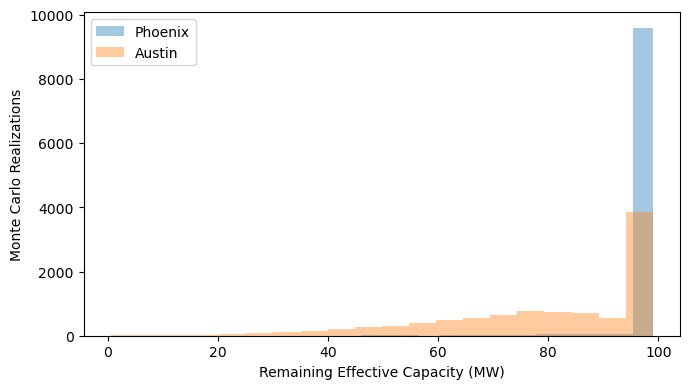

In [64]:
plt.figure(figsize=(7,4))

for loc in locations:

    final = mc_results[loc]
    final = final[final.year==30]

    plt.hist(
        final["effective_capacity_MW_end"],
        bins=20,
        alpha=0.4,
        label=loc
    )

plt.xlabel("Remaining Effective Capacity (MW)")
plt.ylabel("Monte Carlo Realizations")
plt.legend()
plt.tight_layout()

In [57]:
# Sanity check of the Phoenix bar

p_phx = hs.get_annual_site_hail_probability(
    "Phoenix",
    hail_return,
    hail_coverage
)

expected_30yr = 1 - (1 - p_phx)**30

print(f"Annual site-hit probability: {p_phx:.4%}")
print(f"Expected probability of >=1 hit by Year 30: {expected_30yr:.2%}")
print(f"Monte Carlo observed: {88/2000:.2%}")

Annual site-hit probability: 0.1412%
Expected probability of >=1 hit by Year 30: 4.15%
Monte Carlo observed: 4.40%


In [65]:
for loc in ["Phoenix", "Austin"]:
    final = mc_results[loc]
    final = final[final.year == 30]

    print(f"\n{loc}")
    print(final["effective_capacity_MW_end"].describe(
        percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
    ))


Phoenix
count    10000.000000
mean        98.119586
std          5.158357
min         28.213152
5%          99.016432
25%         99.016432
50%         99.016432
75%         99.016432
95%         99.016432
max         99.016432
Name: effective_capacity_MW_end, dtype: float64

Austin
count    10000.000000
mean        80.014632
std         20.399268
min          0.537485
5%          39.815900
25%         67.305287
50%         84.815477
75%         99.016432
95%         99.016432
max         99.016432
Name: effective_capacity_MW_end, dtype: float64


# Figures for PAper 

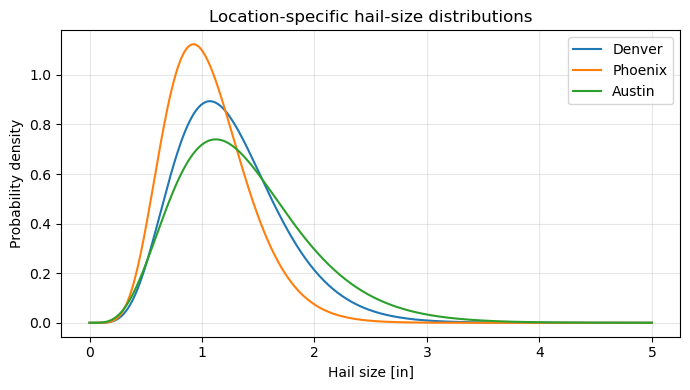

In [66]:
# --------------------------------------------------------------
# Model input figure: location-specific hail-size distributions
# --------------------------------------------------------------

hail_sizes = np.linspace(0, 5, 500)

plt.figure(figsize=(7, 4))

for location in ["Denver", "Phoenix", "Austin"]:
    shape, scale = hs.get_gamma_params(location, hail_dist)

    # Gamma PDF
    from scipy.stats import gamma
    pdf = gamma.pdf(hail_sizes, a=shape, scale=scale)

    plt.plot(
        hail_sizes,
        pdf,
        label=location
    )

plt.xlabel("Hail size [in]")
plt.ylabel("Probability density")
plt.title("Location-specific hail-size distributions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

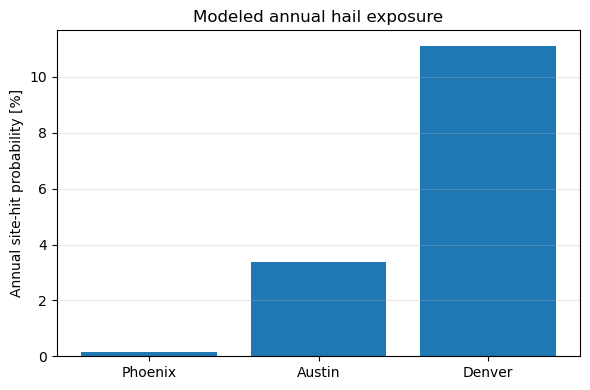

In [67]:
# --------------------------------------------------------------
# Model input figure: annual site-level hail probability
# --------------------------------------------------------------

locations_plot = ["Phoenix", "Austin", "Denver"]

site_probs = []

for loc in locations_plot:
    p_site = hs.get_annual_site_hail_probability(
        loc,
        hail_return,
        hail_coverage
    )
    site_probs.append(100 * p_site)

plt.figure(figsize=(6, 4))

plt.bar(
    locations_plot,
    site_probs
)

plt.ylabel("Annual site-hit probability [%]")
plt.title("Modeled annual hail exposure")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The broken-glass distributions describe project-level damage conditional
on hail-size bin. During each simulated hail event, the corresponding
CDF is sampled to obtain the catastrophic failure fraction, `f_cat`.

The current numerical CDFs were approximated from the available figure
and will be replaced if the original tabulated data become available.

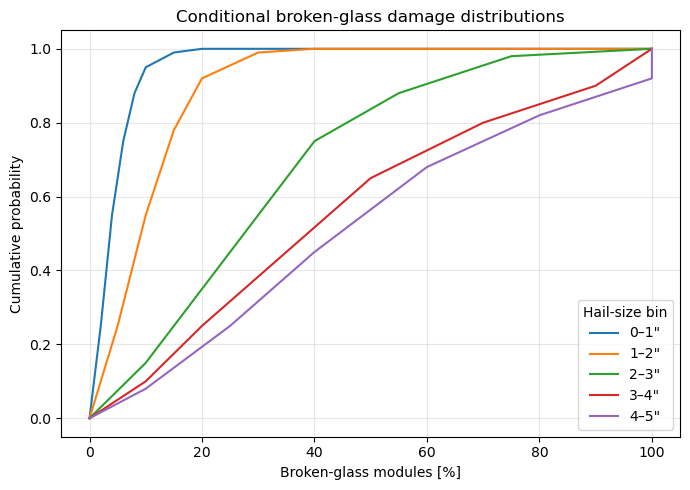

In [68]:
# --------------------------------------------------------------
# Model input figure: conditional broken-glass damage CDFs
# --------------------------------------------------------------

plt.figure(figsize=(7, 5))

labels = {
    "0_1": '0–1"',
    "1_2": '1–2"',
    "2_3": '2–3"',
    "3_4": '3–4"',
    "4_5": '4–5"',
}

for key, df in damage_cdfs.items():

    plt.plot(
        df["broken_glass_percent"],
        df["cumulative_probability"],
        label=labels[key]
    )

plt.xlabel("Broken-glass modules [%]")
plt.ylabel("Cumulative probability")
plt.title("Conditional broken-glass damage distributions")
plt.legend(title="Hail-size bin")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

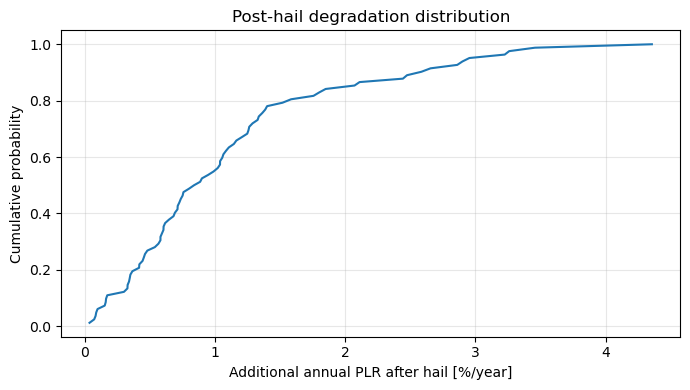

In [69]:
# --------------------------------------------------------------
# Model input figure: post-hail PLR increase distribution
# --------------------------------------------------------------

plt.figure(figsize=(7, 4))

plt.plot(
    plr_cdf["plr_percent_increase_peryear"],
    plr_cdf["cumulative_probability"]
)

plt.xlabel("Additional annual PLR after hail [%/year]")
plt.ylabel("Cumulative probability")
plt.title("Post-hail degradation distribution")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

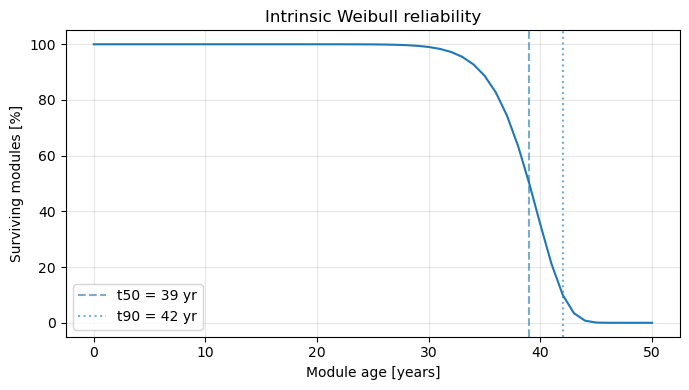

In [70]:
# --------------------------------------------------------------
# Model input figure: intrinsic Weibull reliability
# --------------------------------------------------------------

alpha, beta = hs.weibull_params_from_t50_t90(
    t50=39,
    t90=42
)

S_rel, f_rel = hs.weibull_annual_failure_fraction(
    years,
    alpha,
    beta
)

plt.figure(figsize=(7, 4))

plt.plot(
    years,
    100 * S_rel
)

plt.axvline(39, linestyle="--", alpha=0.6, label="t50 = 39 yr")
plt.axvline(42, linestyle=":", alpha=0.6, label="t90 = 42 yr")

plt.xlabel("Module age [years]")
plt.ylabel("Surviving modules [%]")
plt.title("Intrinsic Weibull reliability")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

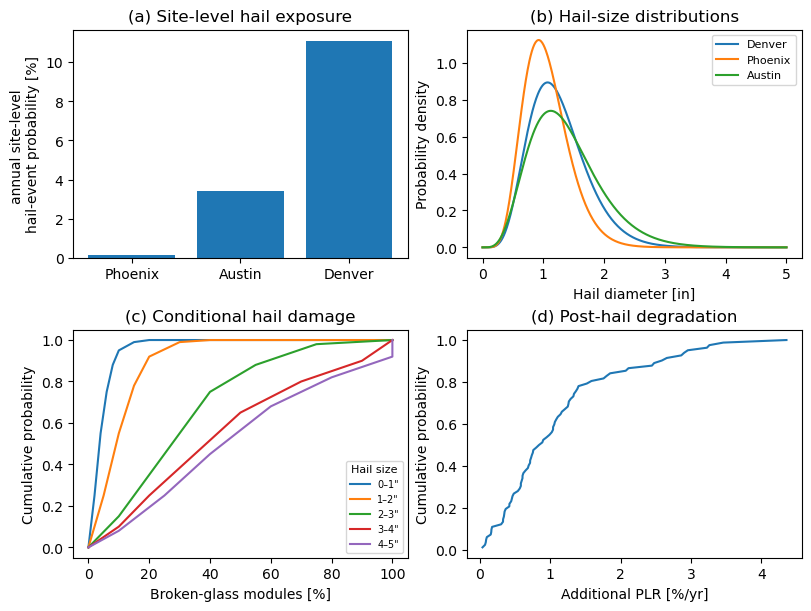

In [74]:
from scipy.stats import gamma

# --------------------------------------------------------------
# Combined model-input figure
# --------------------------------------------------------------

fig, axes = plt.subplots(
    2, 2,
    figsize=(8, 6),
    constrained_layout=True
)

ax1, ax2, ax3, ax4 = axes.flatten()


# ==============================================================
# (a) Annual site-level hail probability
# ==============================================================

locations_plot = ["Phoenix", "Austin", "Denver"]

site_probs = []

for loc in locations_plot:

    p_site = hs.get_annual_site_hail_probability(
        loc,
        hail_return,
        hail_coverage
    )

    site_probs.append(100 * p_site)


ax1.bar(
    locations_plot,
    site_probs
)

ax1.set_ylabel("annual site-level \nhail-event probability [%]")
ax1.set_title("(a) Site-level hail exposure")
#ax1.grid(axis="y", alpha=0.3)


# ==============================================================
# (b) Location-specific hail-size Gamma distributions
# ==============================================================

hail_sizes = np.linspace(0, 5, 500)

for loc in ["Denver", "Phoenix", "Austin"]:

    shape, scale = hs.get_gamma_params(
        loc,
        hail_dist
    )

    pdf = gamma.pdf(
        hail_sizes,
        a=shape,
        scale=scale
    )

    ax2.plot(
        hail_sizes,
        pdf,
        label=loc
    )


ax2.set_xlabel("Hail diameter [in]")
ax2.set_ylabel("Probability density")
ax2.set_title("(b) Hail-size distributions")
ax2.legend(fontsize=8)
#ax2.grid(alpha=0.3)


# ==============================================================
# (c) Conditional broken-glass damage distributions
# ==============================================================

damage_labels = {
    "0_1": '0–1"',
    "1_2": '1–2"',
    "2_3": '2–3"',
    "3_4": '3–4"',
    "4_5": '4–5"',
}

for key, df in damage_cdfs.items():

    ax3.plot(
        df["broken_glass_percent"],
        df["cumulative_probability"],
        label=damage_labels[key]
    )


ax3.set_xlabel("Broken-glass modules [%]")
ax3.set_ylabel("Cumulative probability")
ax3.set_title("(c) Conditional hail damage")
ax3.legend(
    title="Hail size",
    fontsize=7,
    title_fontsize=8
)
#ax3.grid(alpha=0.3)


# ==============================================================
# (d) Post-hail PLR distribution
# ==============================================================

ax4.plot(
    plr_cdf["plr_percent_increase_peryear"],
    plr_cdf["cumulative_probability"]
)

ax4.set_xlabel("Additional PLR [%/yr]")
ax4.set_ylabel("Cumulative probability")
ax4.set_title("(d) Post-hail degradation")
#ax4.grid(alpha=0.3)


# ==============================================================
# Final formatting
# ==============================================================

#fig.suptitle(
#    "Stochastic Reliability Model Inputs",
#    fontsize=13
#)

plt.show()